In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Refined_COVID19_BPS.csv.xls")
df.columns = df.columns.str.lower().str.strip()
df.head()

,country,year,month,date,breakdown_type,breakdown_category,percentage
0,Afghanistan,2020,6,2020-06,Firm Size,Size: Large (100+),2.38
1,Afghanistan,2020,6,2020-06,Firm Size,Size: Large (100+),73.81
2,Afghanistan,2020,6,2020-06,Firm Size,Size: Large (100+),-60.55
3,Afghanistan,2020,6,2020-06,Firm Size,Size: Large (100+),87.50
4,Afghanistan,2020,6,2020-06,Firm Size,Size: Large (100+),-21.49


In [7]:
print(df.shape)
print(df.info())
print(df.columns.tolist())

(12577, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12577 entries, 0 to 12576
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             12577 non-null  object 
 1   year                12577 non-null  int64  
 2   month               12577 non-null  int64  
 3   date                12577 non-null  object 
 4   breakdown_type      12577 non-null  object 
 5   breakdown_category  12577 non-null  object 
 6   percentage          12577 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 687.9+ KB
None
['country', 'year', 'month', 'date', 'breakdown_type', 'breakdown_category', 'percentage']


In [8]:
print(df.isnull().sum())
df = df.drop_duplicates()

country               0
year                  0
month                 0
date                  0
breakdown_type        0
breakdown_category    0
percentage            0
dtype: int64


In [9]:
df.describe()

,year,month,percentage
count,12324.000000,12324.00000,12324.000000
mean,2020.395002,6.99505,20.320529
std,0.488871,2.68484,27.516010
min,2020.000000,1.00000,-80.490000
25%,2020.000000,6.00000,4.280000
50%,2020.000000,6.00000,13.765000
75%,2021.000000,9.00000,34.400000
max,2021.000000,12.00000,99.950000


In [10]:
df['country'].value_counts().head(10)

,count
country,
Kenya,665
Turkiye,643
Viet Nam,621
Romania,592
Poland,552
Bulgaria,542
South Africa,517
Pakistan,496
Philippines,445


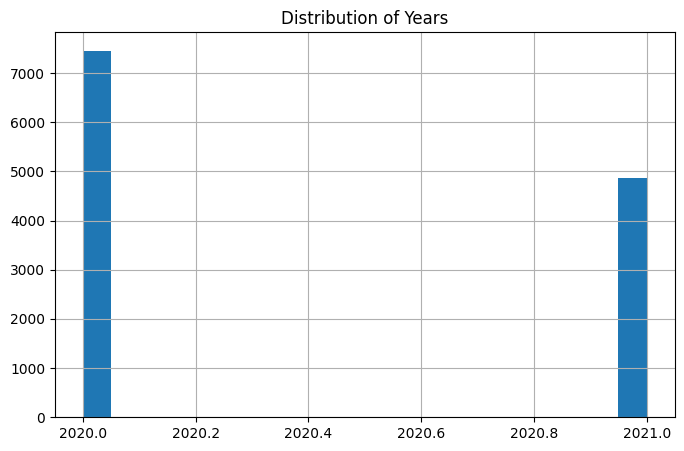

In [11]:
plt.figure(figsize=(8,5))
df['year'].hist(bins=20)
plt.title("Distribution of Years")
plt.show()

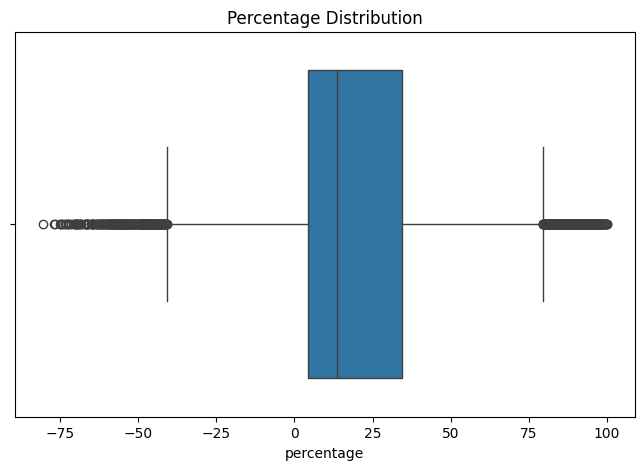

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['percentage'])
plt.title("Percentage Distribution")
plt.show()

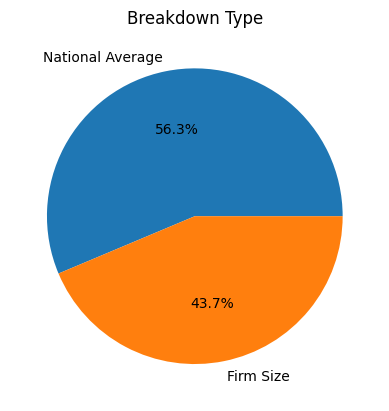

In [13]:
df['breakdown_type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Breakdown Type")
plt.ylabel("")
plt.show()

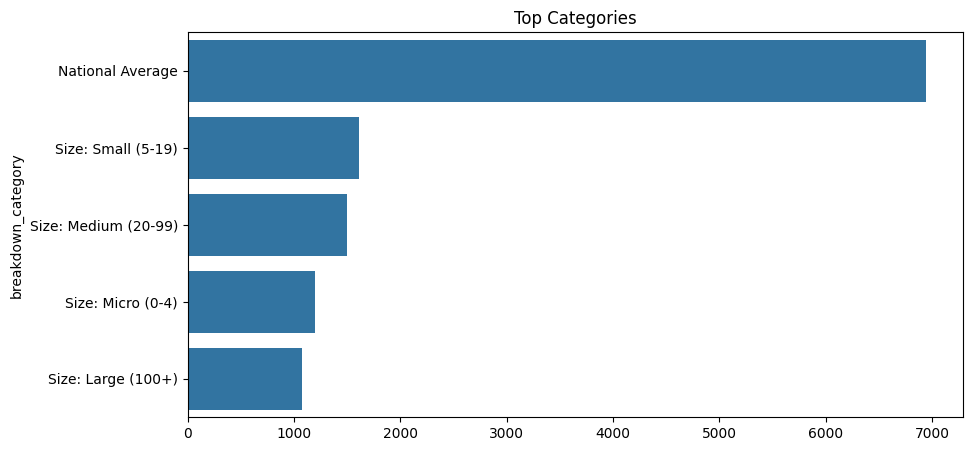

In [14]:
top_cat = df['breakdown_category'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top Categories")
plt.show()

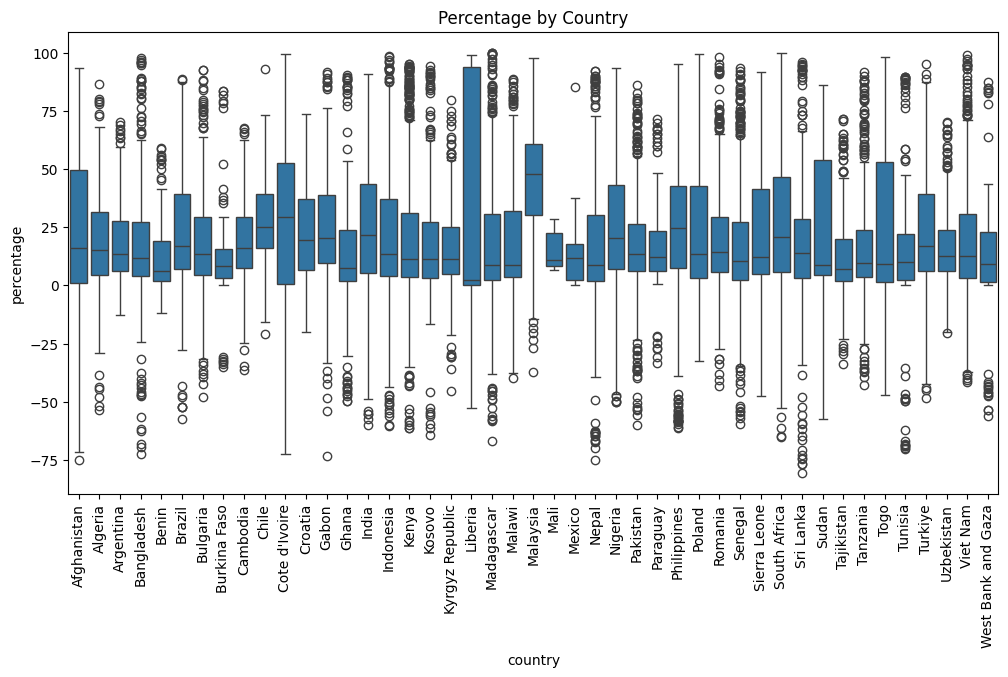

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='percentage', data=df)
plt.xticks(rotation=90)
plt.title("Percentage by Country")
plt.show()

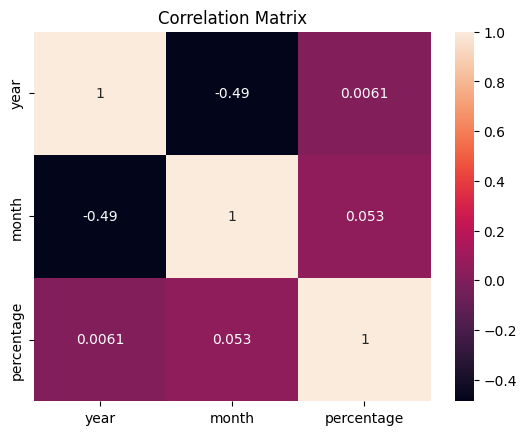

In [16]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [18]:
total = len(df)

for val in df['breakdown_type'].unique():
    prob = len(df[df['breakdown_type']==val]) / total
    print(f"{val} : {prob:.2f}")

Firm Size : 0.44
National Average : 0.56


In [19]:
prob = len(df[df['percentage'] > 50]) / len(df)
print(prob)

0.14889646218760144


In [21]:
prob = len(df[(df['country']=='USA') & (df['percentage'] > 50)]) / len(df)
print(prob)

0.0


In [22]:
pd.crosstab(df['country'], df['breakdown_type'])

breakdown_type,Firm Size,National Average
country,,
Afghanistan,42,41
Algeria,52,54
Argentina,91,99
Bangladesh,125,168
Benin,68,71
Brazil,72,118
Bulgaria,252,290
Burkina Faso,46,61
Cambodia,80,89


In [42]:
import streamlit as st
import pandas as pd

df = pd.read_csv("/content/Refined_COVID19_BPS.csv.xls")
df.columns = df.columns.str.lower().str.strip()

st.title("Data Dashboard")

st.write(df.head())

st.bar_chart(df['country'].value_counts())

2026-03-24 17:45:08.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:08.995 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.020 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.029 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 17:45:09.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [41]:
!pip install streamlit

In [43]:
import streamlit as st

In [59]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.239.102.55:8501

  Stopping...
^C


In [46]:
%%writefile app.py
import streamlit as st
import pandas as pd

df = pd.read_csv("impact_pays.csv")
df.columns = df.columns.str.lower().str.strip()

st.title("Data Dashboard")

st.write(df.head())

st.bar_chart(df['country'].value_counts())

Overwriting app.py


In [34]:
import os
print(os.listdir())

['.config', 'Refined_COVID19_BPS.csv.xls', 'app.py', 'sample_data']


In [47]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://every-beds-kneel.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.239.102.55:8501

  Stopping...
^C


In [39]:
!curl ipv4.icanhazip.com

35.239.102.55


In [45]:
!pkill streamlit
!pkill npx

In [56]:
!curl ipv4.icanhazip.com

35.239.102.55


In [52]:
!streamlit run app.py & npx --yes localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://famous-regions-cheer.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.239.102.55:8501

  Stopping...
^C


In [53]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv("Refined_COVID19_BPS.csv.xls")
except:
    df = pd.read_excel("Refined_COVID19_BPS.csv.xls")

df.columns = df.columns.str.lower().str.strip()

st.title("Data Dashboard - Projet Analyse")

st.write("Aperçu des données :")
st.write(df.head())

st.subheader("Distribution par catégorie")
column_to_show = df.columns[0]
st.bar_chart(df[column_to_show].value_counts())

st.subheader("Statistiques descriptives")
st.write(df.describe())

Overwriting app.py


In [58]:
import scipy.stats as stats

total = len(df)
region_counts = df.iloc[:, 0].value_counts()
prob_simple = region_counts / total
print(prob_simple)

threshold = df.iloc[:, -1].mean()
high_impact = df[df.iloc[:, -1] > threshold]
prob_cond = len(high_impact) / total
print(prob_cond)

data_col = df.iloc[:, -1]
mu, std = stats.norm.fit(data_col)
print(mu, std)

country
Kenya                 0.053351
Turkiye               0.051523
Viet Nam              0.050091
Romania               0.047945
Poland                0.044764
Bulgaria              0.043890
South Africa          0.041107
Pakistan              0.040471
Philippines           0.035621
Malaysia              0.033235
Senegal               0.033076
Indonesia             0.032361
Uzbekistan            0.029737
Tajikistan            0.028385
Tanzania              0.028067
Madagascar            0.027431
Kyrgyz Republic       0.026874
Kosovo                0.026238
Ghana                 0.024887
Bangladesh            0.024251
Nepal                 0.024092
India                 0.021945
Tunisia               0.021229
Sri Lanka             0.019878
Brazil                0.015266
Argentina             0.015186
Chile                 0.014550
Sierra Leone          0.014073
Cambodia              0.013517
Croatia               0.013199
Benin                 0.012324
Paraguay              0.011927


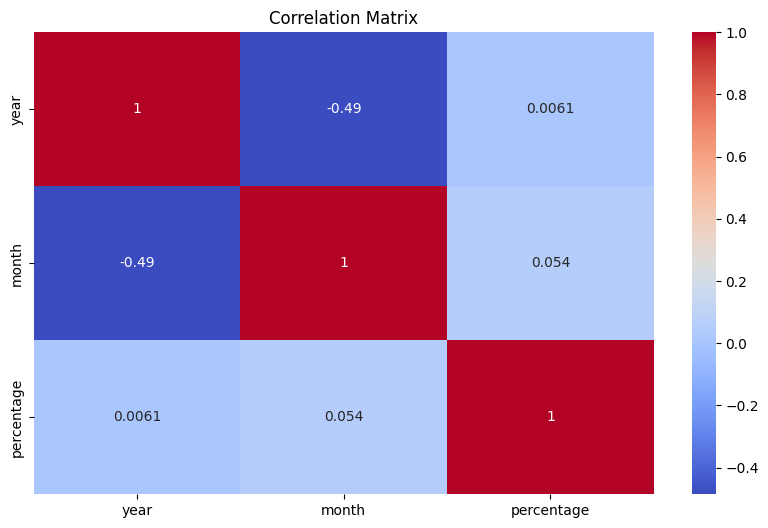

year         2020  2021
country                
Afghanistan    87     0
Algeria       106     0
Argentina       0   191
Bangladesh    126   179
Benin           0   155


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print(pd.crosstab(df.iloc[:, 0], df.iloc[:, 1]).head())